In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import bayes_fit as bf
import glob
import re
import pandas as pd
from scipy.stats import ttest_ind, ttest_ind_from_stats
import t_test

# %matplotlib widget

In [3]:
# df = pd.read_excel(r'C:\Users\teole\OneDrive - McGill University\Research stuff\gpcr_gprotein results\abberior_results.xlsx', sheet_name='AT1RB2R',  ) # AT1RB2R # FP_full_data # FP_truncated_data
df1 = pd.read_excel(r"C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\Jan-Feb results\Batch_results_4.xlsx")
df2 = pd.read_excel(r"C:\Users\teo\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\Mar-May results\Batch_results_4.xlsx")
# df = pd.read_excel(r'C:\Users\teo\OneDrive - McGill University\Research stuff\gpcr_gprotein results\results_so_far.xlsx', sheet_name='improved_fits_cut_data')
# df = pd.read_excel(r'C:\Users\teo\OneDrive - McGill University\Research stuff\gpcr_gprotein results\pca_cumulant_results.xlsx')

df = pd.concat([df1, df2], ignore_index=True)

In [4]:
# common filtering (should be all i need)

df.dropna(inplace=True)
df['std_err'] = (df.loc[:, 'full_95_max'].to_numpy() - df.loc[:, 'full_95_min'].to_numpy())/4
df = df[df['full_data_KD'] > 0]
lyng13vals = df.loc[df['Treatment']=='lyn-g13', 'full_data_KD'].to_numpy()
lyng13errs = df.loc[df['Treatment']=='lyn-g13', 'std_err'].to_numpy()

df = df[df['extrema'] != 1]
df = df[df['full_data_KD'] < 1500]


df

,Unnamed: 0,file name,Treatment,full_data_KD,full_95_min,full_95_max,KD_range_min,KD_range_max,extrema,std_err
0,0,20250124_at1r-g13_measurement1b_set10_cumulant...,at1r-g13,436.098316,418.942361,451.938799,335.383730,730.540189,0,8.249110
2,2,20250124_at1r-g13_measurement3a_set10_cumulant...,at1r-g13,139.221604,130.139719,148.828633,65.643024,273.349726,0,4.672228
3,3,20250124_at1r-g13_measurement3b_set10_cumulant...,at1r-g13,137.273206,130.400251,143.813599,72.734443,274.904115,0,3.353337
4,4,20250124_at1r-g13_measurement3c_set10_cumulant...,at1r-g13,129.733112,123.412819,135.687601,78.448956,258.024299,0,3.068696
5,5,20250124_at1r-g13_measurement3_set10_cumulant_...,at1r-g13,127.731445,118.950539,137.892207,58.046833,322.294536,0,4.735417
...,...,...,...,...,...,...,...,...,...,...
824,504,20250504_b2r_gq_measurement6_set10_cumulant_LS...,b2r-gq,178.244469,165.258666,192.973948,62.812540,328.420784,0,6.928820
825,505,20250504_b2r_gq_measurement7a_set10_cumulant_L...,b2r-gq,297.400105,271.193571,326.733033,91.888868,486.791531,0,13.884866
827,507,20250504_b2r_gq_measurement7_set10_cumulant_LS...,b2r-gq,435.794199,381.476694,491.587723,64.440057,579.911808,0,27.527757
828,508,20250504_b2r_gq_measurement8_set10_cumulant_LS...,b2r-gq,144.196200,133.571530,154.474790,73.507862,306.995374,0,5.225815


In [5]:
# get get all data
at1gqvals = df.loc[df['Treatment']=='at1r-gq', 'full_data_KD'].to_numpy()
at1gqerrs = df.loc[df['Treatment']=='at1r-gq', 'std_err'].to_numpy()     
at1g13vals = df.loc[df['Treatment']=='at1r-g13', 'full_data_KD'].to_numpy()
at1g13errs = df.loc[df['Treatment']=='at1r-g13', 'std_err'].to_numpy()
n111ggqvals = df.loc[df['Treatment']=='n111g-gq', 'full_data_KD'].to_numpy()
n111ggqerrs = df.loc[df['Treatment']=='n111g-gq', 'std_err'].to_numpy()
n111gg13vals = df.loc[df['Treatment']=='n111g-g13', 'full_data_KD'].to_numpy()
n111gg13errs = df.loc[df['Treatment']=='n111g-g13', 'std_err'].to_numpy()
fpgqvals = df.loc[df['Treatment']=='fp-gq', 'full_data_KD'].to_numpy()
fpgqerrs = df.loc[df['Treatment']=='fp-gq', 'std_err'].to_numpy()
fpg13vals = df.loc[df['Treatment']=='fp-g13', 'full_data_KD'].to_numpy()
fpg13errs = df.loc[df['Treatment']=='fp-g13', 'std_err'].to_numpy()
b2rgqvals = df.loc[df['Treatment']=='b2r-gq', 'full_data_KD'].to_numpy()
b2rgqerrs = df.loc[df['Treatment']=='b2r-gq', 'std_err'].to_numpy()
b2rg13vals = df.loc[df['Treatment']=='b2r-g13', 'full_data_KD'].to_numpy()
b2rg13errs = df.loc[df['Treatment']=='b2r-g13', 'std_err'].to_numpy()


In [6]:
fpgqvals = fpgqvals.copy()
fpg13vals = fpg13vals.copy()
fpgqerrs = fpgqerrs.copy()
fpg13errs = fpg13errs.copy()
print('N samples')
print('fpq', len(fpgqerrs))
print('fp13', len(fpg13errs))

at1gqvals = at1gqvals.copy()
at1g13vals = at1g13vals.copy()
at1gqerrs = at1gqerrs.copy()
at1g13errs = at1g13errs.copy()
print('at1q', len(at1gqerrs))
print('at113', len(at1g13errs))

b2rgqvals = b2rgqvals.copy()
b2rg13vals = b2rg13vals.copy()
b2rgqerrs = b2rgqerrs.copy()
b2rg13errs = b2rg13errs.copy()
print('b2rq', len(b2rgqerrs))
print('b2r13', len(b2rg13errs))

mutgqvals = n111ggqvals.copy()
mutg13vals = n111gg13vals.copy()
mutgqerrs = n111ggqerrs.copy()
mutg13errs = n111gg13errs.copy()
print('n111gq', len(mutgqerrs))
print('n111g13', len(mutg13errs))

lynvals = lyng13vals.copy()
lynerrs = lyng13errs.copy()
print('lyn13', len(lynerrs))
print()
print('Results: (inverse variance weighted average, standard error of the weighted mean), sqrt of unbiased weighted variance')
print('at1-gq mean:', t_test.weighted_avg(at1gqvals, at1gqerrs), 'std dev:', np.sqrt(t_test.weighted_var(at1gqvals, at1gqerrs)))
print('at1-g13 mean:', t_test.weighted_avg(at1g13vals, at1g13errs), 'std dev:', np.sqrt(t_test.weighted_var(at1g13vals, at1g13errs)))
print('n111g-gq mean:', t_test.weighted_avg(mutgqvals, mutgqerrs), 'std dev:', np.sqrt(t_test.weighted_var(mutgqvals, mutgqerrs)))
print('n111g-g13 mean:', t_test.weighted_avg(mutg13vals, mutg13errs), 'std dev:', np.sqrt(t_test.weighted_var(mutg13vals, mutg13errs)))
print('fp-gq mean:', t_test.weighted_avg(fpgqvals, fpgqerrs), 'std dev:', np.sqrt(t_test.weighted_var(fpgqvals, fpgqerrs)))
print('fp-g13 mean:', t_test.weighted_avg(fpg13vals, fpg13errs), 'std dev:', np.sqrt(t_test.weighted_var(fpg13vals, fpg13errs)))
print('b2r-gq mean:', t_test.weighted_avg(b2rgqvals, b2rgqerrs), 'std dev:', np.sqrt(t_test.weighted_var(b2rgqvals, b2rgqerrs)))
print('b2r-g13 mean:', t_test.weighted_avg(b2rg13vals, b2rg13errs), 'std dev:', np.sqrt(t_test.weighted_var(b2rg13vals, b2rg13errs)))
print('lyn-g13 mean:', t_test.weighted_avg(lynvals, lynerrs), 'std dev:', np.sqrt(t_test.weighted_var(lynvals, lynerrs)))


# x1 = np.random.uniform(0.9, 1.1, len(gqvals))
# x2 = np.random.uniform(1.9, 2.1, len(g13vals))

# plt.figure()
# plt.errorbar(x1, gqvals[:], yerr=gqerrs[:], alpha=0.9, color='b', fmt='.', markersize=10, capsize=5, capthick=1, label=r'AT1R G$\alpha_{q}$')
# plt.errorbar(x2, g13vals[:], yerr=g13errs[:], alpha=0.9, color='r', fmt='.', markersize=10, capsize=5, capthick=1, label=r'AT1R G$\alpha_{13}$')
# plt.xticks([1.2, 1.9], [r'FP-G$\alpha q$', r'FP-G$\alpha 13$'], fontsize=12)
# # plt.legend()
# plt.xlim(xmin=0.5, xmax=2.5)
# # plt.ylim(ymin=0, ymax=400)
# plt.title('AT1R(N111G) G protein $K_D$ values', fontsize=16)
# # plt.title('PCA denoised results (3 PCs kept)')
# plt.ylabel(r'$K_D$ ($\mu$m$^{-2}$)', fontsize=12)
# # plt.plot([1.1, 1.1, 1.9, 1.9], [325, 335, 335, 325], color='k')
# # plt.text(1.5, 345, f"p < 0.00075", {'ha':'center', 'va':'bottom'})
# # plt.ylim(0, 760)
# plt.show()

# gqavg = np.average(gqvals[:])#, weights=1/gqvals[:]**2)
# print(np.average(gqvals[:], weights=1/gqerrs[:]**2), np.sqrt(1/np.sum(1/gqerrs[:]**2)))
# gqerr = np.std(gqvals)
# # gqerr = 1/np.sqrt(np.sum(1/gqerrs[:]**2))
# g13avg = np.average(g13vals[:])#, weights=1/g13vals[:]**2)
# print( np.average(g13vals[:], weights=1/g13errs[:]**2), np.sqrt(1/np.sum(1/g13errs[:]**2)))
# # g13err = 1/np.sqrt(np.sum(1/g13errs[:]**2))
# g13err = np.std(g13vals)

# print(f'at1r g13 kd avg {gqavg} (+/-) {gqerr}')
# print(f'at1r(n111g) g13 kd avg {g13avg} (+/-) {g13err}')

N samples
fpq 59
fp13 42
at1q 53
at113 66
b2rq 23
b2r13 37
n111gq 58
n111g13 84
lyn13 46

Results: (inverse variance weighted average, standard error of the weighted mean), sqrt of unbiased weighted variance
at1-gq mean: (181.054499662639, 0.5081157576492549) std dev: 105.8141768289894
at1-g13 mean: (24.688609118507078, 0.23689194263320099) std dev: 36.51237161567989
n111g-gq mean: (177.54629229229687, 0.42231230860949637) std dev: 175.01543314824877
n111g-g13 mean: (24.508028618007117, 0.22113336305829237) std dev: 46.25592551204424
fp-gq mean: (142.8134806566993, 0.4783925121690464) std dev: 97.90185145620325
fp-g13 mean: (101.70125311439436, 0.8403316693552771) std dev: 72.18820033172973
b2r-gq mean: (122.96335783725483, 0.9618657482013575) std dev: 66.48888018517746
b2r-g13 mean: (42.07093374129451, 0.44653638598864503) std dev: 43.13148707841219
lyn-g13 mean: (138.62725863475896, 0.060701679498541626) std dev: 97.85368917223941


In [7]:
alldata = data = [at1gqvals, at1g13vals, mutgqvals, mutg13vals, fpgqvals, fpg13vals, b2rgqvals, b2rg13vals]
allerrs = [at1gqerrs, at1g13errs, mutgqerrs, mutg13errs, fpgqerrs, fpg13errs, b2rgqerrs, b2rg13errs]
labels = [r'AT1R - G$_{\alpha q}$' + "(N=53)", r'AT1R - G$_{\alpha 13}$' + "(N=66)", r'AT1R(N111G) - G$_{\alpha q}$'+ "(N=58)", r'AT1R(N111G) - G$_{\alpha 13}$'+ "(N=85)", r'FP - G$_{\alpha q}$'+ "(N=59)", r'FP - G$_{\alpha 13}$'+ "(N=42)", r'B2R - G$_{\alpha q}$'+ "(N=23)", r'B2R - G$_{\alpha 13}$'+ "(N=37)", r'LYN - G$_{\alpha 13}$'+ "(N=46)"]

lynavg = t_test.weighted_avg(lynvals, lynerrs)[0]
lynstd = np.sqrt(t_test.weighted_var(lynvals, lynerrs))
for i in range(len(alldata)):
    print(labels[i], 'vs. Lyn-g13 (N=46)')
    print(ttest_ind_from_stats(t_test.weighted_avg(alldata[i], allerrs[i])[0], np.sqrt(t_test.weighted_var(alldata[i], allerrs[i])), len(alldata[i]), lynavg, lynstd, len(lynerrs), equal_var=False))
    print()

# Gq/G13 comparisons
for i in range(4):
    print(labels[i*2], 'vs.', labels[i*2+1])
    u1 = t_test.weighted_avg(alldata[i*2], allerrs[i*2])[0] 
    std1 = np.sqrt(t_test.weighted_var(alldata[i*2], allerrs[i*2]))
    nobs1 = len(alldata[i*2])

    u2 = t_test.weighted_avg(alldata[i*2+1], allerrs[i*2+1])[0] 
    std2 = np.sqrt(t_test.weighted_var(alldata[i*2+1], allerrs[i*2+1]))
    nobs2 = len(alldata[i*2 + 1])
    print(ttest_ind_from_stats(u1, std1, nobs1, u2, std2, nobs2, equal_var=False))
    print()

# at1 vs at1(n111g comparisons)
uat1q = t_test.weighted_avg(at1gqvals, at1gqerrs)[0]
stdat1q = np.sqrt(t_test.weighted_var(at1gqvals, at1gqerrs))
uat113 = t_test.weighted_avg(at1g13vals, at1g13errs)[0]
stdat113 = np.sqrt(t_test.weighted_var(at1g13vals, at1g13errs))
umutq = t_test.weighted_avg(mutgqvals, mutgqerrs)[0]
stdmutq = np.sqrt(t_test.weighted_var(mutgqvals, mutgqerrs))
umut13 = t_test.weighted_avg(mutg13vals, mutg13errs)[0]
stdmut13 = np.sqrt(t_test.weighted_var(mutg13vals, mutg13errs))
print('at1-gq (N=53) vs. at1(n111g)-gq (n=58)')
print(ttest_ind_from_stats(uat1q, stdat1q, len(at1gqvals), umutq, stdmutq, len(mutgqvals), equal_var=False))
print()
print('at1-g13 (n=66) vs. at1(n111g)-g13 (n=85)')
print(ttest_ind_from_stats(uat113, stdat113, len(at1g13vals), umut13, stdmut13, len(mutg13vals), equal_var=False))


AT1R - G$_{\alpha q}$(N=53) vs. Lyn-g13 (N=46)
Ttest_indResult(statistic=2.071675668424022, pvalue=0.040961096494421194)

AT1R - G$_{\alpha 13}$(N=66) vs. Lyn-g13 (N=46)
Ttest_indResult(statistic=-7.5398385117043905, pvalue=5.59236352128285e-10)

AT1R(N111G) - G$_{\alpha q}$(N=58) vs. Lyn-g13 (N=46)
Ttest_indResult(statistic=1.434311512375373, pvalue=0.15485289346321277)

AT1R(N111G) - G$_{\alpha 13}$(N=85) vs. Lyn-g13 (N=46)
Ttest_indResult(statistic=-7.466093014379741, pvalue=5.73887672206915e-10)

FP - G$_{\alpha q}$(N=59) vs. Lyn-g13 (N=46)
Ttest_indResult(statistic=0.21745113513037123, pvalue=0.8283141471808283)

FP - G$_{\alpha 13}$(N=42) vs. Lyn-g13 (N=46)
Ttest_indResult(statistic=-2.025863003295314, pvalue=0.0460118708637093)

B2R - G$_{\alpha q}$(N=23) vs. Lyn-g13 (N=46)
Ttest_indResult(statistic=-0.7828358928831226, pvalue=0.43676868057535756)

B2R - G$_{\alpha 13}$(N=37) vs. Lyn-g13 (N=46)
Ttest_indResult(statistic=-6.0062296750134125, pvalue=9.598399599867099e-08)

AT1R - 

In [8]:
def gradient_error_bars(axis, data, data_std, xidx=0, colors=['b', 'r', 'k']):
    """
    make a scater plot with alpha gradient ~1/std^2
    """
    quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    y_data = data.copy()
    y_std = data_std.copy()
    x1 = np.random.uniform(xidx+0.9, xidx+1.1, len(data))
    weights = 1 / y_std**2
    quantvals = [np.quantile(weights, q) for q in quantiles]
    for j in range(len(weights)):
        for idx, k in enumerate(quantvals):
            if weights[j] < k:
                break
        axis.errorbar(x1[j], y_data[j], y_std[j], alpha=quantiles[idx], color=colors[xidx], fmt='.', capsize=5, capthick=1., linewidth=1)

def plain_error_bars(axis, data, data_std, xidx=0, colors=['gray']):
    x1 = np.random.uniform(xidx+0.9, xidx+1.1, len(data))
    axis.errorbar(x1, data, data_std, alpha=0.7, color=colors[0], fmt='.', capsize=0, capthick=0., linewidth=1)


def fill_violins(axis, data, data_std, fill_func, scatter_colors=['b', 'r', 'k']):
    """ 
    annotate violin plots with at least 2 different distributions
    """
    parts = axis.violinplot(data, showextrema=False, showmeans=False, bw_method='scott')
    # for body in parts["bodies"]:
    #     body.set_facecolor('gray')
    for i in range(len(data)):
        fill_func(axis, data[i], data_std[i], xidx=i, colors=scatter_colors)
        quants = np.quantile(data[i], [0.25, 0.75])
        # axis.hlines(min(data[i]), i+0.9, i+1.1, color='k')
        # axis.hlines(max(data[i]), i+0.9, i+1.1, color='k')
        axis.vlines(i+1, min(data[i]), max(data[i]), color='k', alpha=1)
        axis.vlines(i+1, quants[0], quants[1], linewidth=5, color='k', alpha=1)
        # axis.scatter([i+1], [np.mean(data[i])], marker='o', color='white', zorder=100)

def significance_bar(ax, yheight, text, pos, color='k', fontsize=12):
    start = pos[0] + 0.05
    end = pos[1] - 0.05
    ax.plot([start, start, end, end], [yheight-10, yheight, yheight, yheight-10], color=color)
    ax.text((start+end)/2, yheight, text, {'ha':'center', 'va':'bottom'}, color=color, fontsize=fontsize)
    

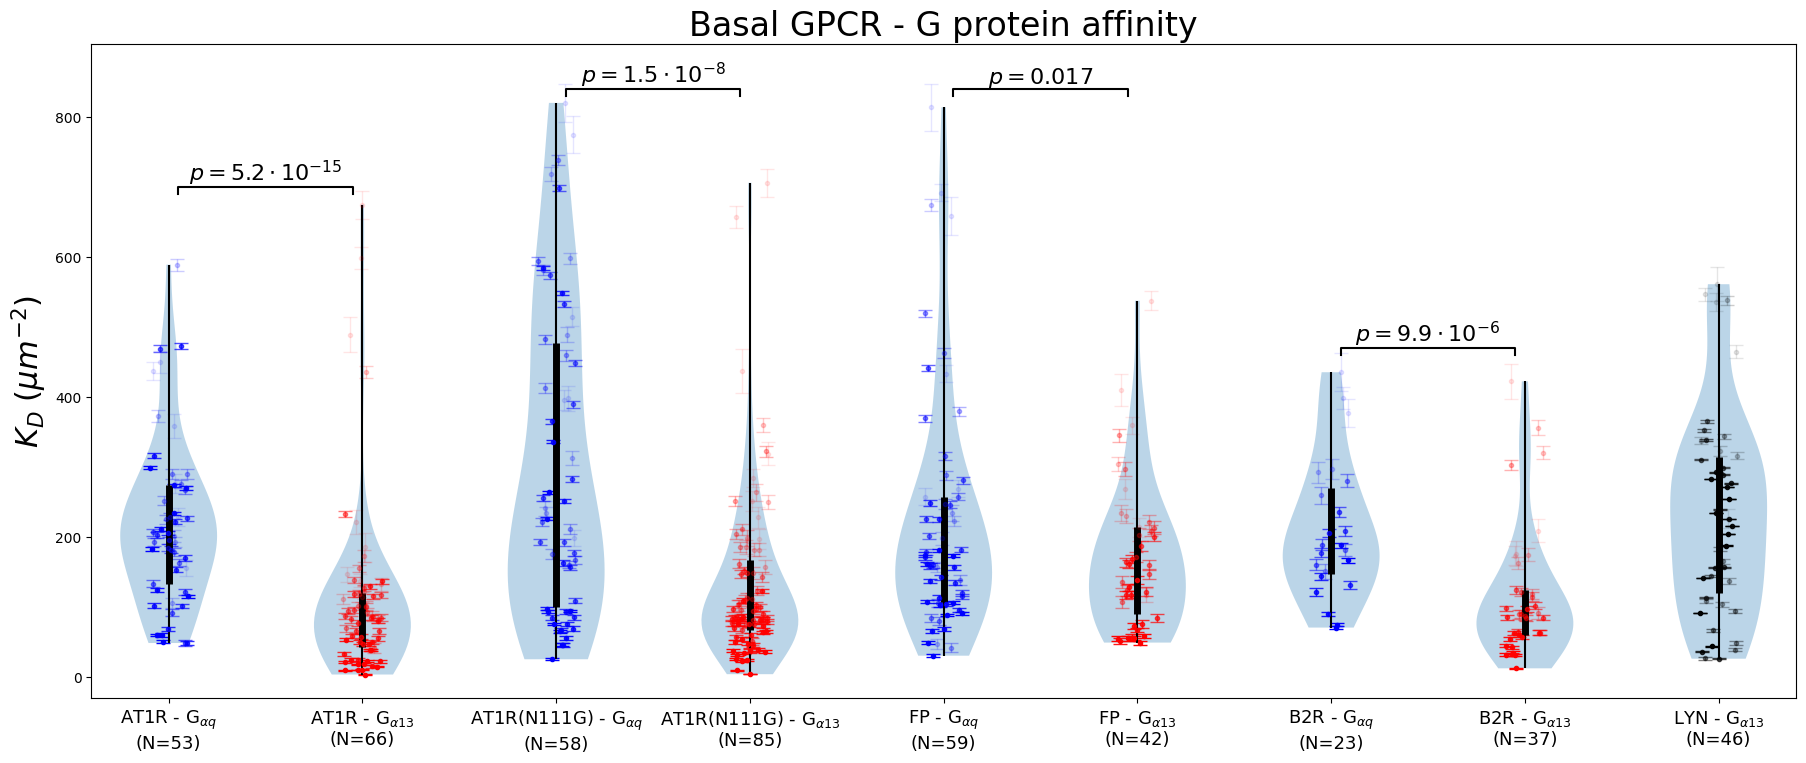

In [9]:
fig, ax = plt.subplots(figsize=(22,8.5))
# ax.set_title(r'Prostaglandin F2$\alpha$ (FP) receptor $K_D$ distributions')
ax.set_title(r'Basal GPCR - G protein affinity', fontsize=24)

fill_violins(ax, [at1gqvals, at1g13vals, mutgqvals, mutg13vals, fpgqvals, fpg13vals, b2rgqvals, b2rg13vals, lynvals], [at1gqerrs, at1g13errs, mutgqerrs, mutg13errs, fpgqerrs, fpg13errs, b2rgqerrs, b2rg13errs, lynerrs], gradient_error_bars, scatter_colors=['b', 'r', 'b', 'r', 'b', 'r', 'b', 'r', 'k'])
# fill_violins(ax, [g13vals], [g13errs])
significance_bar(ax, 700, r"$p = 5.2 \cdot 10^{-15}$", [1,2], color='k', fontsize=16)
significance_bar(ax, 840, r"$p = 1.5 \cdot 10^{-8}$", [3, 4], color="k", fontsize=16)
significance_bar(ax, 840, r"$p = 0.017$", [5, 6], color='k', fontsize=16)
significance_bar(ax, 470, r"$p = 9.9 \cdot 10^{-6}$", [7, 8], color='k', fontsize=16)




labels = [r'AT1R - G$_{\alpha q}$' + "\n(N=53)", r'AT1R - G$_{\alpha 13}$' + "\n(N=66)", r'AT1R(N111G) - G$_{\alpha q}$'+ "\n(N=58)", r'AT1R(N111G) - G$_{\alpha 13}$'+ "\n(N=85)", r'FP - G$_{\alpha q}$'+ "\n(N=59)", r'FP - G$_{\alpha 13}$'+ "\n(N=42)", r'B2R - G$_{\alpha q}$'+ "\n(N=23)", r'B2R - G$_{\alpha 13}$'+ "\n(N=37)", r'LYN - G$_{\alpha 13}$'+ "\n(N=46)"]
ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], labels=labels, fontsize=13)
# ax.set_xticks([1], labels=labels)
ax.set_xlim(0.6, 9.4)
ax.set_ylim(-30, 905)
ax.set_ylabel(r'$K_D$ ($\mu m^{-2}$)', fontsize=22)




plt.show()

Text(0, 0.5, '$K_D$ ($\\mu m^{-2}$)')

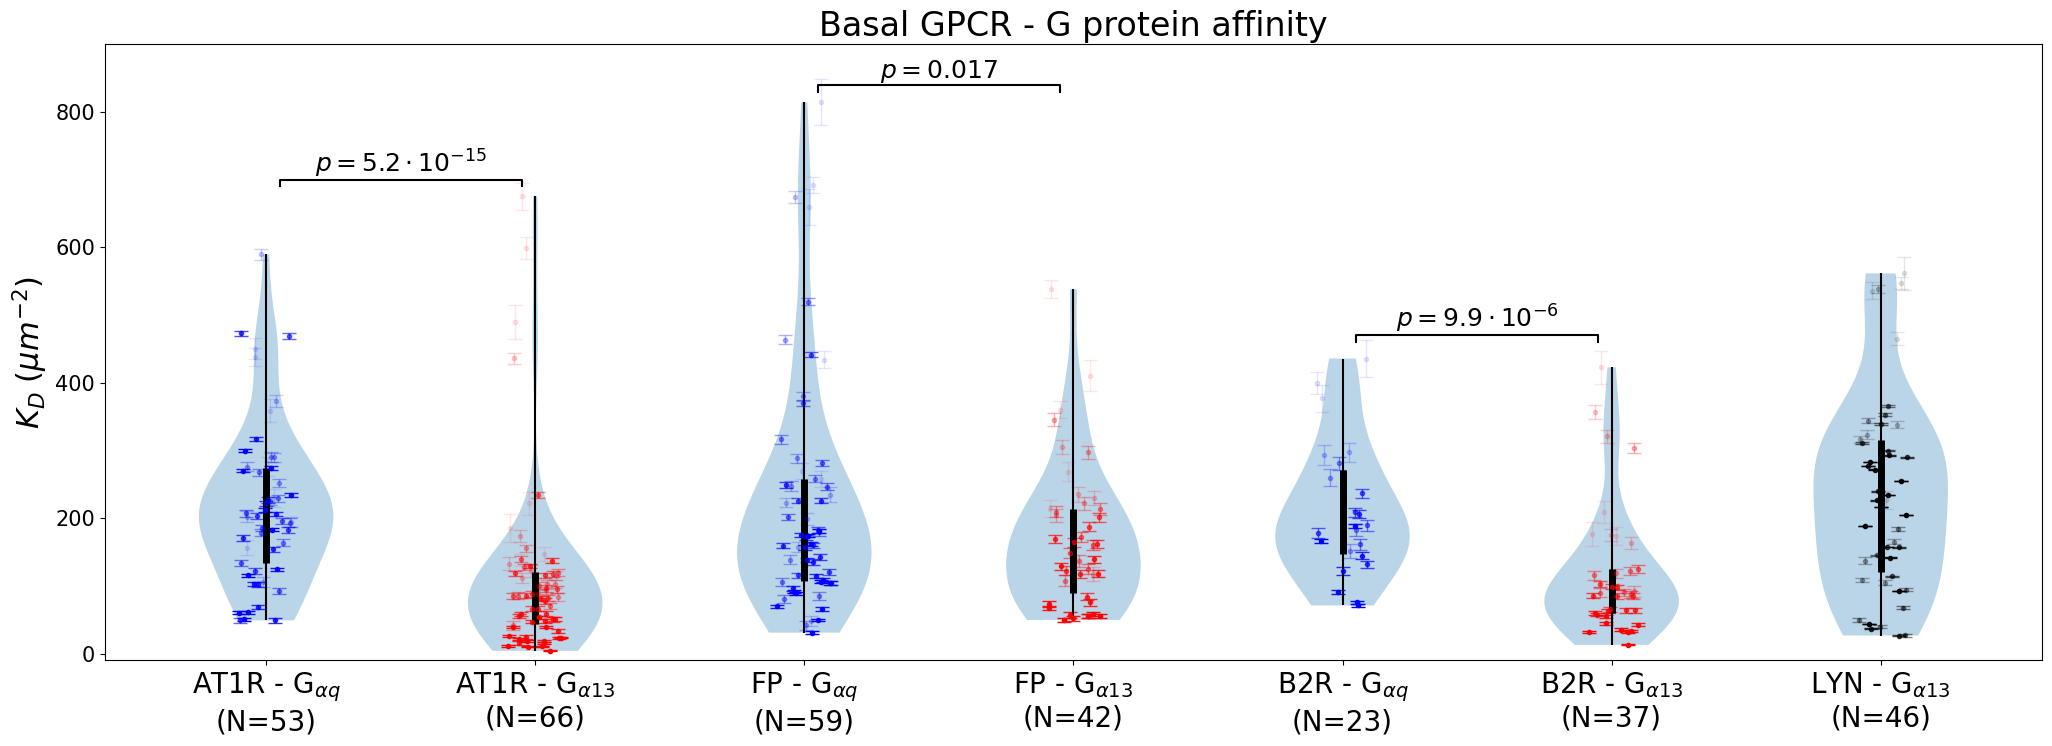

In [15]:
fig, ax = plt.subplots(figsize=(25,8))
# ax.set_title(r'Prostaglandin F2$\alpha$ (FP) receptor $K_D$ distributions')
ax.set_title(r'Basal GPCR - G protein affinity', fontsize=24)

fill_violins(ax, [at1gqvals, at1g13vals, fpgqvals, fpg13vals, b2rgqvals, b2rg13vals, lynvals], [at1gqerrs, at1g13errs, fpgqerrs, fpg13errs, b2rgqerrs, b2rg13errs, lynerrs], gradient_error_bars, scatter_colors=['b', 'r', 'b', 'r', 'b', 'r', 'k'])
# fill_violins(ax, [g13vals], [g13errs])
significance_bar(ax, 700, r"$p = 5.2 \cdot 10^{-15}$", [1,2], color='k', fontsize=18)
significance_bar(ax, 840, r"$p = 0.017$", [3, 4], color='k', fontsize=18)
significance_bar(ax, 470, r"$p = 9.9 \cdot 10^{-6}$", [5, 6], color='k', fontsize=18)




labels = [r'AT1R - G$_{\alpha q}$' + "\n(N=53)", r'AT1R - G$_{\alpha 13}$' + "\n(N=66)", r'FP - G$_{\alpha q}$'+ "\n(N=59)", r'FP - G$_{\alpha 13}$'+ "\n(N=42)", r'B2R - G$_{\alpha q}$'+ "\n(N=23)", r'B2R - G$_{\alpha 13}$'+ "\n(N=37)", r'LYN - G$_{\alpha 13}$'+ "\n(N=46)"]
ax.set_xticks([1, 2, 3, 4, 5, 6, 7], labels=labels, fontsize=20)
# ax.set_xticks([1], labels=labels)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlim(0.4, 7.6)
ax.set_ylim(-10, 900)
ax.set_ylabel(r'$K_D$ ($\mu m^{-2}$)', fontsize=22)

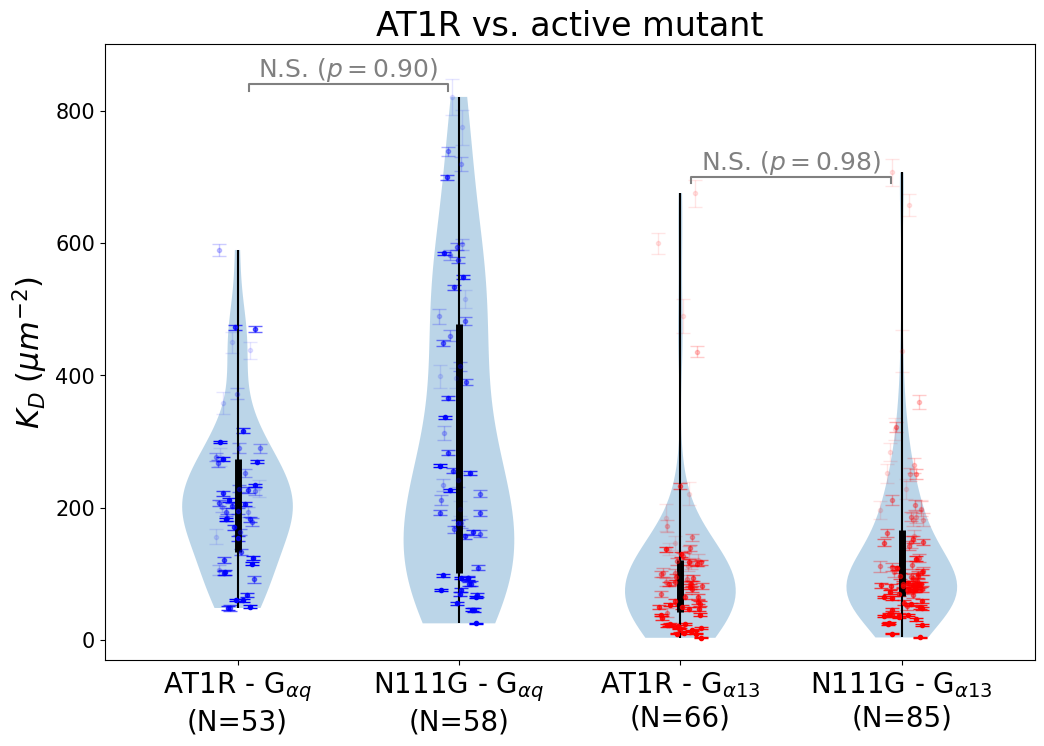

In [16]:
fig, ax = plt.subplots(figsize=(12,8))
# ax.set_title(r'Prostaglandin F2$\alpha$ (FP) receptor $K_D$ distributions')
ax.set_title(r'AT1R vs. active mutant', fontsize=24)

fill_violins(ax, [at1gqvals, mutgqvals, at1g13vals, mutg13vals], [at1gqerrs, mutgqerrs, at1g13errs, mutg13errs], gradient_error_bars, scatter_colors=['b', 'b', 'r', 'r'])
# fill_violins(ax, [g13vals], [g13errs])
significance_bar(ax, 840, r"N.S. $(p = 0.90)$", [1,2], color='gray', fontsize=18)
significance_bar(ax, 700, r"N.S. $(p = 0.98)$", [3, 4], color="gray", fontsize=18)
# significance_bar(ax, 840, r"$p = 0.017$", [5, 6], color='k')
# significance_bar(ax, 470, r"$p = 9.9 \cdot 10^{-6}$", [7, 8], color='k')




labels = [r'AT1R - G$_{\alpha q}$' + "\n(N=53)", r'N111G - G$_{\alpha q}$'+ "\n(N=58)", r'AT1R - G$_{\alpha 13}$' + "\n(N=66)", r'N111G - G$_{\alpha 13}$'+ "\n(N=85)"]
ax.set_xticks([1, 2, 3, 4], labels=labels, fontsize=20)
# ax.set_xticks([1], labels=labels)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlim(0.4, 4.6)
ax.set_ylim(-30, 900)
ax.set_ylabel(r'$K_D$ ($\mu m^{-2}$)', fontsize=22)

plt.show()


# make some histogram views of KD distributions

[0, 10, 20, 30, 50, 75, 100, 150, 200, 250, 300, 350, 400, 500, 600, 700]


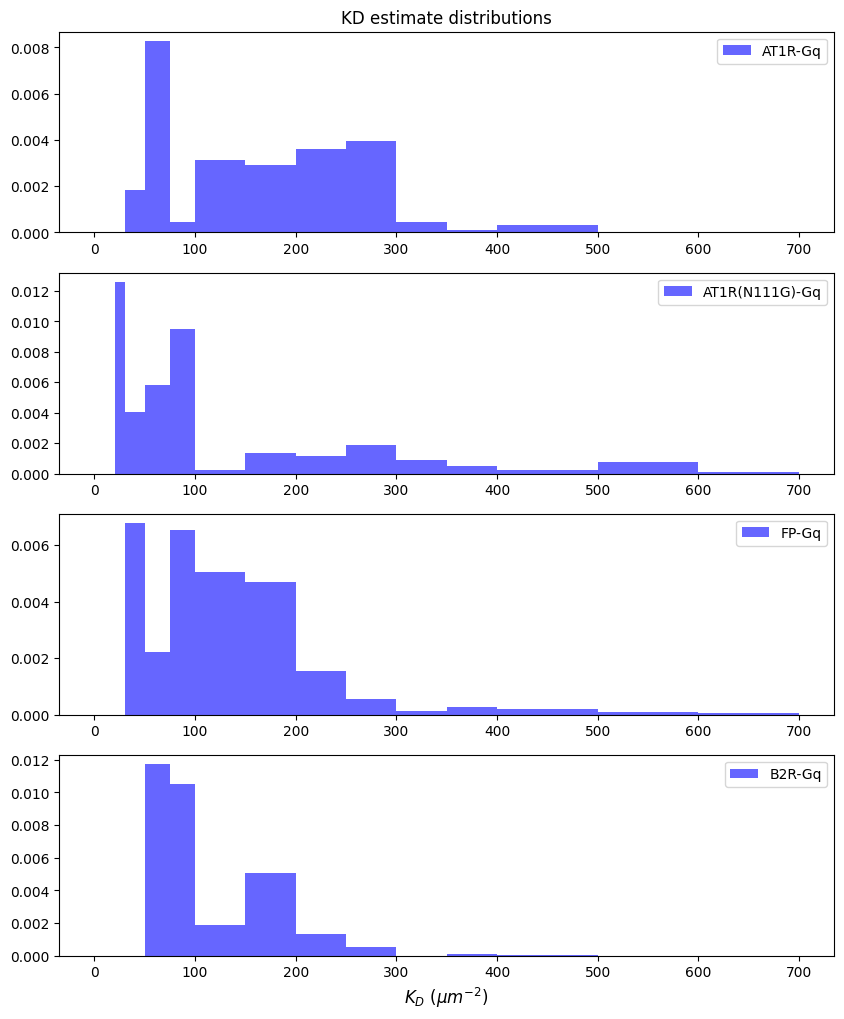

In [12]:
data = [at1gqvals, at1g13vals, mutgqvals, mutg13vals, fpgqvals, fpg13vals, b2rgqvals, b2rg13vals]
errs = [at1gqerrs, at1g13errs, mutgqerrs, mutg13errs, fpgqerrs, fpg13errs, b2rgqerrs, b2rg13errs]
labels = ['AT1R-Gq', 'AT1R-G13', 'AT1R(N111G)-Gq', 'AT1R(N111G)-G13', 'FP-Gq', 'FP-G13', 'B2R-Gq', 'B2R-G13']

bins = np.linspace(0, 800, 17, endpoint=True)
bins = [0, 10, 20, 30, 50, 75, 100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
print(bins)

fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(10, 12))
ax[0].set_title('KD estimate distributions')
for i in range(len(ax)):
    ax[i].hist(data[i*2], bins=bins, density=True, weights=1/errs[i*2]**2, color='b', alpha=0.6, label=labels[i*2])
    # ax[i].hist(data[i*2 + 1], bins=bins, density=True, color='r', weights=-(1/errs[i*2+1]**2), alpha=0.6, label=labels[i*2 + 1])
    ax[i].legend()
ax[i].set_xlabel(r'$K_D$ $(\mu m ^{-2})$', fontsize=12)
plt.show()




In [2]:
densdf1 = pd.read_excel(r'C:\Users\teole\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\MarMay_Results_4GPCR_Gprotein_concentrations.xlsx')
densdf2 = pd.read_excel(r'C:\Users\teole\OneDrive - McGill University\Research stuff\my_images\abberior_new_FPs\JanFeb_Results_4GPCR_Gprotein_concentrations.xlsx')
densdf = pd.concat([densdf1, densdf2], ignore_index=True)
densdf

,Unnamed: 0,file name,Treatment,R_total,G_total,extrema
0,0,20250319_at1r-n111g_g13_measurement1a_set10_cu...,n111g-g13,157.571585,100.784362,0
1,1,20250319_at1r-n111g_g13_measurement1b_set10_cu...,n111g-g13,157.235363,83.330624,0
2,2,20250319_at1r-n111g_g13_measurement1_set10_cum...,n111g-g13,160.353830,171.530739,0
3,3,20250319_at1r-n111g_g13_measurement2a_set10_cu...,n111g-g13,35.556490,41.336885,0
4,4,20250319_at1r-n111g_g13_measurement2b_set10_cu...,n111g-g13,35.386660,32.319327,0
...,...,...,...,...,...,...
826,315,20250207_lyn-g13_measurement6_set10_cumulant_L...,lyn-g13,277.944350,23.919021,1
827,316,20250207_lyn-g13_measurement7a_set10_cumulant_...,lyn-g13,105.551282,28.953382,0
828,317,20250207_lyn-g13_measurement7_set10_cumulant_L...,lyn-g13,110.031912,50.807941,0
829,318,20250207_lyn-g13_measurement8a_set10_cumulant_...,lyn-g13,282.275644,18.148345,1


In [3]:
cutdf = densdf[densdf['extrema'] == 1]
densdf = densdf[densdf['extrema'] == 0]


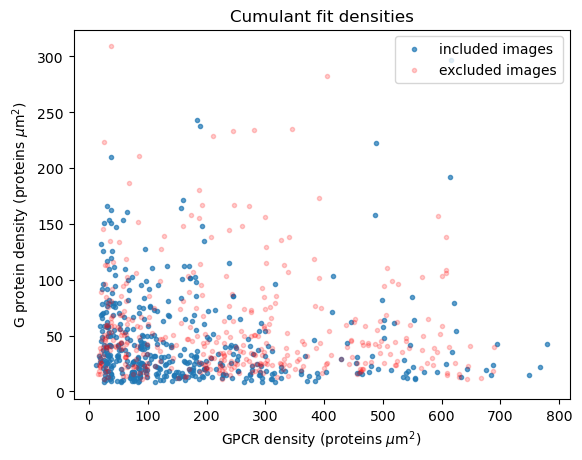

In [7]:
Rdens = densdf['R_total'].to_numpy()
Gdens = densdf['G_total'].to_numpy() 

Rbad = cutdf['R_total'].to_numpy()
Gbad = cutdf['G_total'].to_numpy()

plt.figure()
plt.title('Cumulant fit densities')
plt.scatter(Rdens, Gdens, marker='.', color='tab:blue', alpha=0.7, label='included images')
plt.scatter(Rbad, Gbad, marker='.', color='r', alpha=0.2, label='excluded images')

# plt.xlim(-20, 820)
# plt.ylim(-20, 820)
plt.xlabel(r'GPCR density (proteins $\mu$m$^2$)')
plt.ylabel(r'G protein density (proteins $\mu$m$^2$)')
plt.legend()
plt.show()
